In [7]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df_full = pd.read_csv("all_data_recompute.csv", parse_dates=["period"])
df_values = df_full[["period", "value"]]
df_values.head()

,period,value
0,2019-01-01,119601
1,2019-01-02,136354
2,2019-01-03,136364
3,2019-01-04,136034
4,2019-01-05,124696


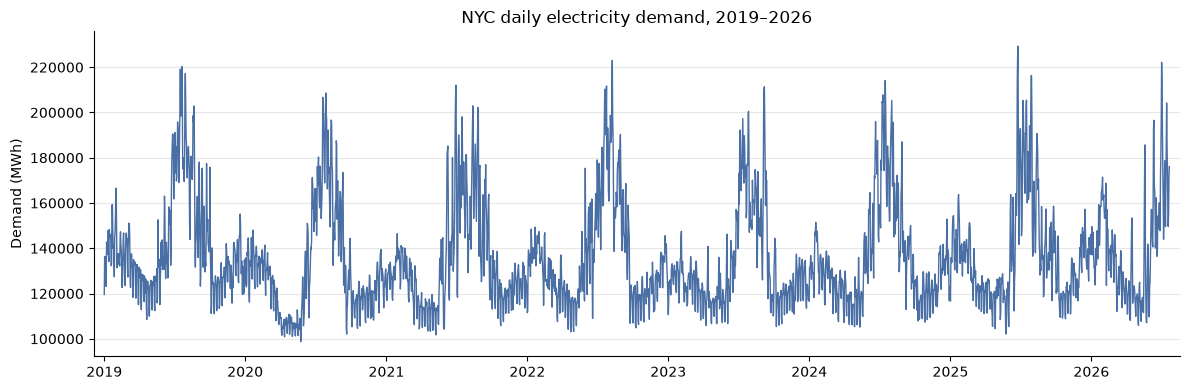

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_values["period"], df_values["value"], linewidth=1, color="#4a6fa5")

ax.set_title("NYC daily electricity demand, 2019–2026")
ax.set_xlabel("")
ax.set_ylabel("Demand (MWh)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.margins(x=0.01)

fig.tight_layout()

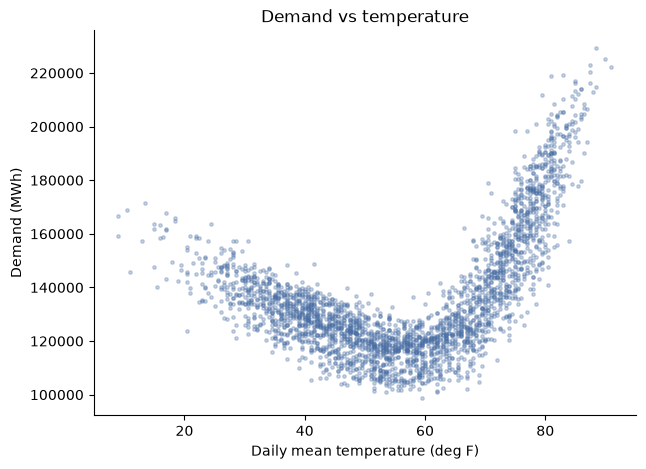

In [10]:
# Plot demand vs. temperature 
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_full["tavg"], df_full["value"], s=6, alpha=0.3, color="#4a6fa5")
ax.set_xlabel("Daily mean temperature (deg F)")
ax.set_ylabel("Demand (MWh)")
ax.set_title("Demand vs temperature")
ax.spines[["top", "right"]].set_visible(False)

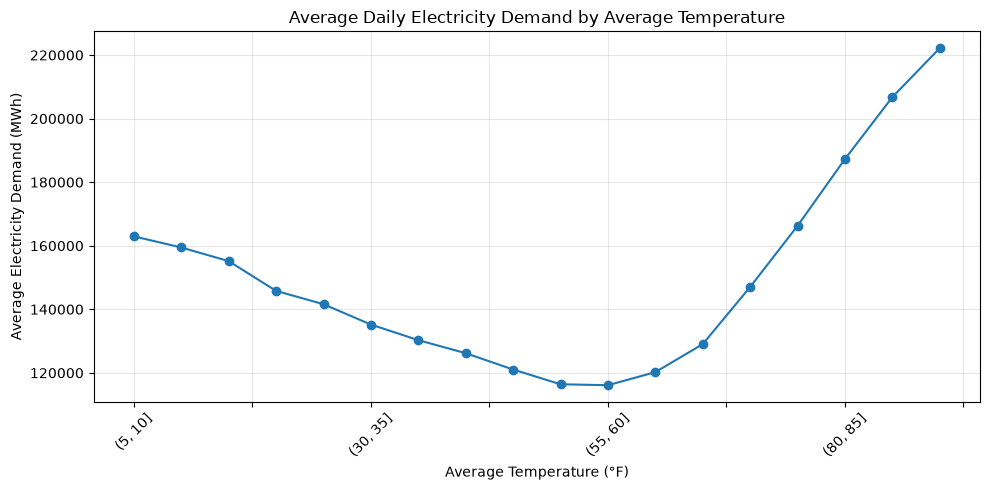

In [11]:
bins = pd.cut(df_full["tavg"], range(0, 105, 5))
ax = (
    df_full.groupby(bins, observed=True)["value"]
    .mean()
    .plot(marker="o", figsize=(10, 5))
)

ax.set_title("Average Daily Electricity Demand by Average Temperature")
ax.set_xlabel("Average Temperature (°F)")
ax.set_ylabel("Average Electricity Demand (MWh)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

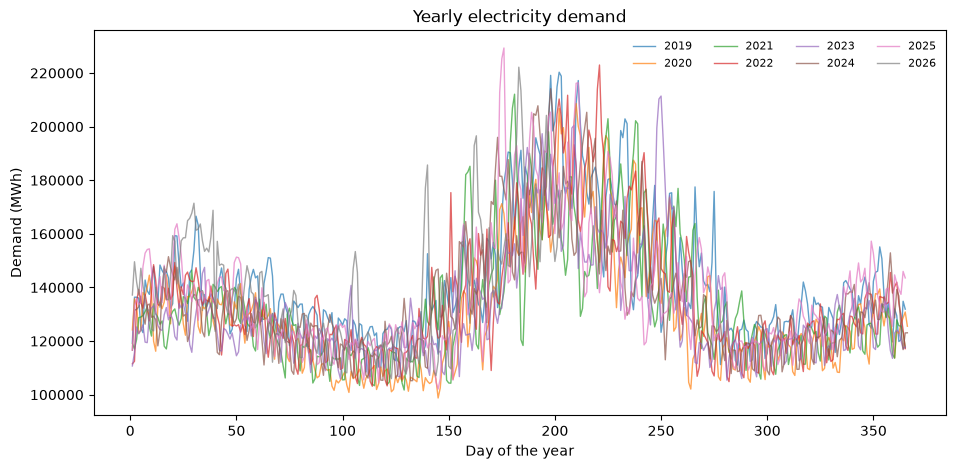

In [12]:
# Layer demands year by year
fig, ax = plt.subplots(figsize=(11, 5))
for yr, g in df_full.groupby(df_full["period"].dt.year):
    ax.plot(g["period"].dt.dayofyear, g["value"], linewidth=1, alpha=0.7,
label=yr)
ax.set_xlabel("Day of the year")
ax.set_ylabel("Demand (MWh)")
ax.set_title("Yearly electricity demand")
ax.legend(frameon=False, ncol=4, fontsize=8)

<Axes: title={'center': 'value'}, xlabel='day_name'>

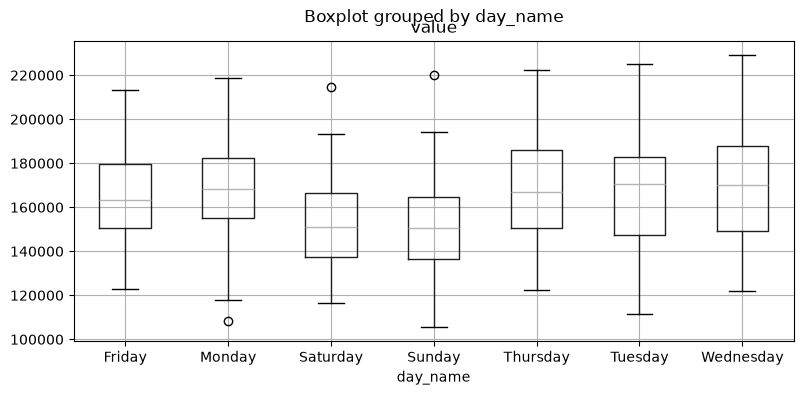

In [13]:
summer = df_full[df_full["period"].dt.month.isin([6,7,8])]
summer.boxplot(column="value", by="day_name", figsize=(9,4))

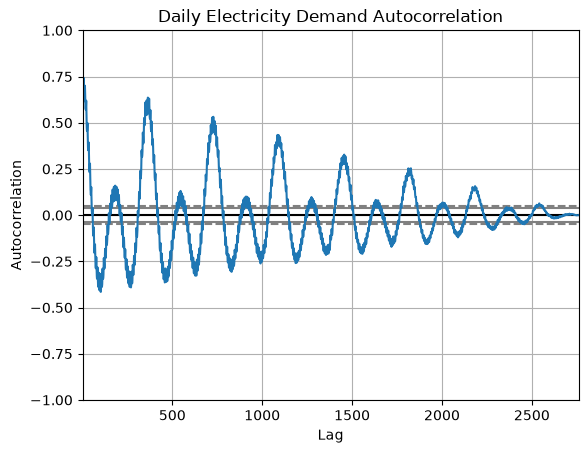

In [14]:
from pandas.plotting import autocorrelation_plot
ax = autocorrelation_plot(df_full["value"])
ax.set_title("Daily Electricity Demand Autocorrelation")
plt.show()

<Axes: title={'center': 'Feature correlation map'}>

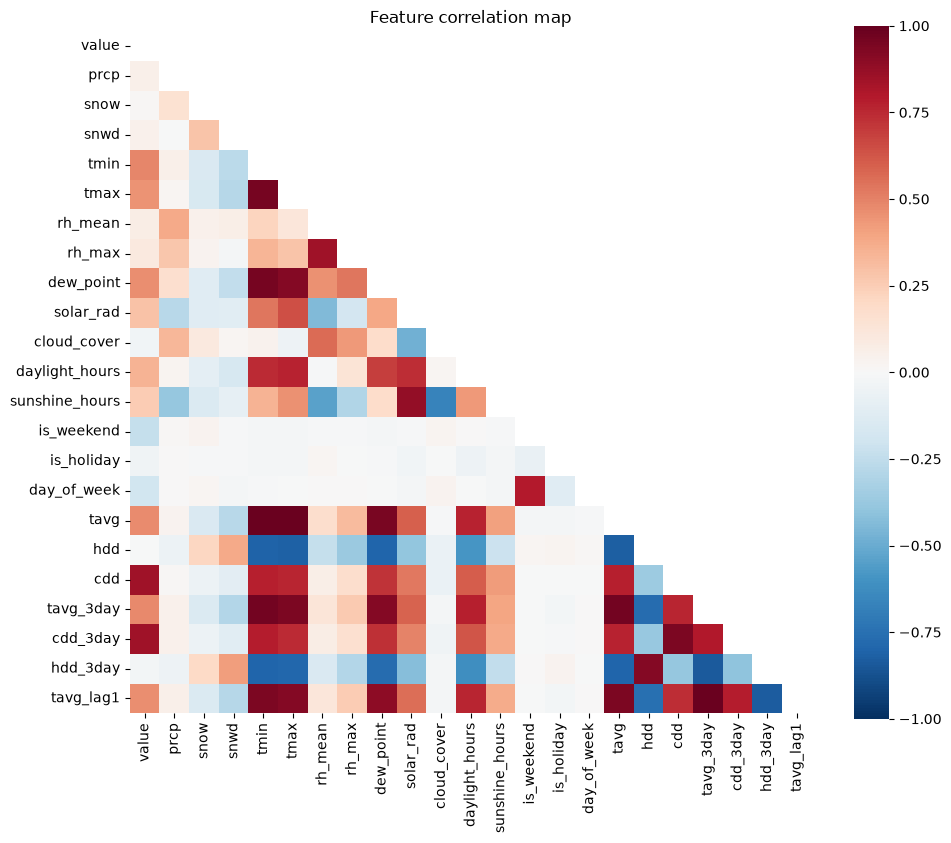

In [15]:
import numpy as np
num = df_full.select_dtypes("number").drop(columns=["is_imputed"])
c = num.corr()
fig, ax = plt.subplots(figsize=(11, 9))
ax.set_xlabel("Feature name")
ax.set_ylabel("Feature name")
ax.set_title("Feature correlation map")
sns.heatmap(c, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
            mask=np.triu(np.ones_like(c, dtype=bool)), ax=ax)

c:\Users\yumi\nyc-electricity\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\yumi\nyc-electricity\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


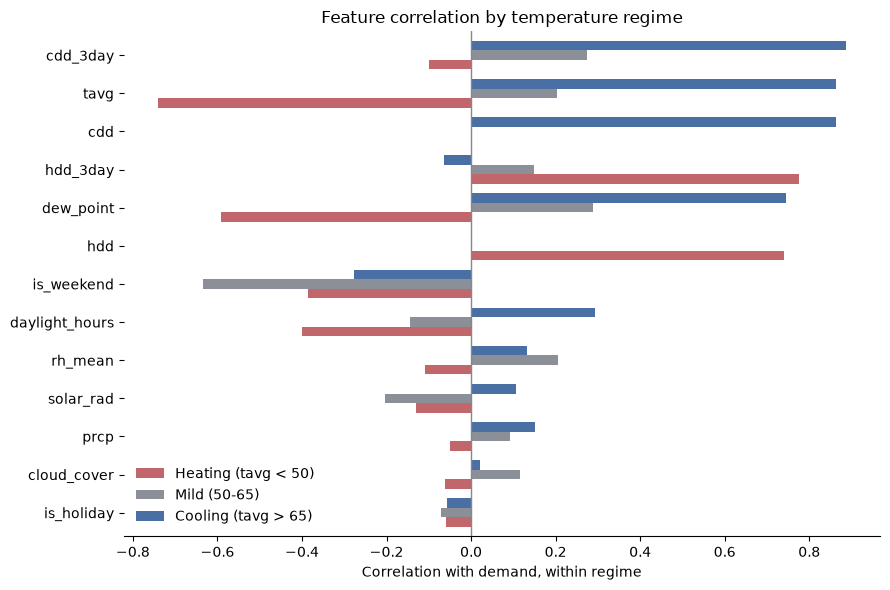

In [ ]:
obs = df_full[df_full["is_imputed"] == 0]
regimes = {
    "Heating (tavg < 50)": obs[obs["tavg"] < 50],
    "Mild (50-65)":        obs[(obs["tavg"] >= 50) & (obs["tavg"] <= 65)],
    "Cooling (tavg > 65)": obs[obs["tavg"] > 65],
}
feats = ["cdd", "hdd", "cdd_3day", "hdd_3day", "tavg", "dew_point", "solar_rad",
        "daylight_hours", "rh_mean", "cloud_cover", "prcp", "is_weekend",
"is_holiday"]

tbl = pd.DataFrame({k: g[feats].corrwith(g["value"]) for k, g in regimes.items()})

fig, ax = plt.subplots(figsize=(9, 6))
tbl.loc[tbl.abs().max(axis=1).sort_values().index].plot.barh(
    ax=ax, width=0.75, color=["#c1666b", "#8a8f98", "#4a6fa5"])
ax.axvline(0, color="#888", linewidth=1)
ax.set_xlabel("Correlation with demand, within regime")
ax.set_title("Feature correlation by temperature regime")
ax.legend(frameon=False, title=None)
ax.spines[["top", "right", "left"]].set_visible(False)
fig.tight_layout()